# Applied Question #9 on page 554

## Load Data

In [1]:
import pandas as pd
# Load the uploaded file
df = pd.read_csv("USArrests.csv", index_col=0)
print(df.head())

            Murder  Assault  UrbanPop  Rape
States                                     
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6


## (a) Hierarchical Clustering (Complete Linkage, Euclidean Distance)

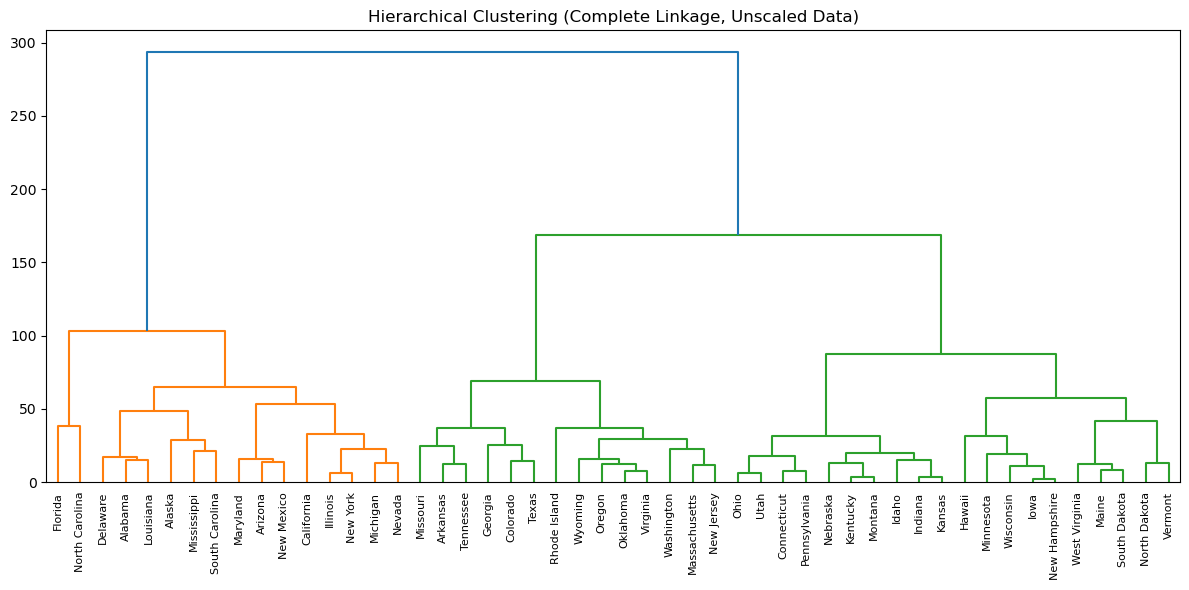

In [2]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Complete linkage with Euclidean distance
Z = linkage(df.values, method='complete', metric='euclidean')

plt.figure(figsize=(12,6))
dendrogram(Z, labels=df.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering (Complete Linkage, Unscaled Data)")
plt.tight_layout()
plt.show()

## (b) Cut Dendrogram Into 3 Clusters

In [3]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, 3, criterion='maxclust')

df["Cluster_Unscaled"] = clusters

for cluster in sorted(df["Cluster_Unscaled"].unique()):
    print(f"\nCluster {cluster}:")
    print(df[df["Cluster_Unscaled"] == cluster].index.tolist())


Cluster 1:
['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']

Cluster 2:
['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']

Cluster 3:
['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']


## (c) Hierarchical Clustering After Scaling

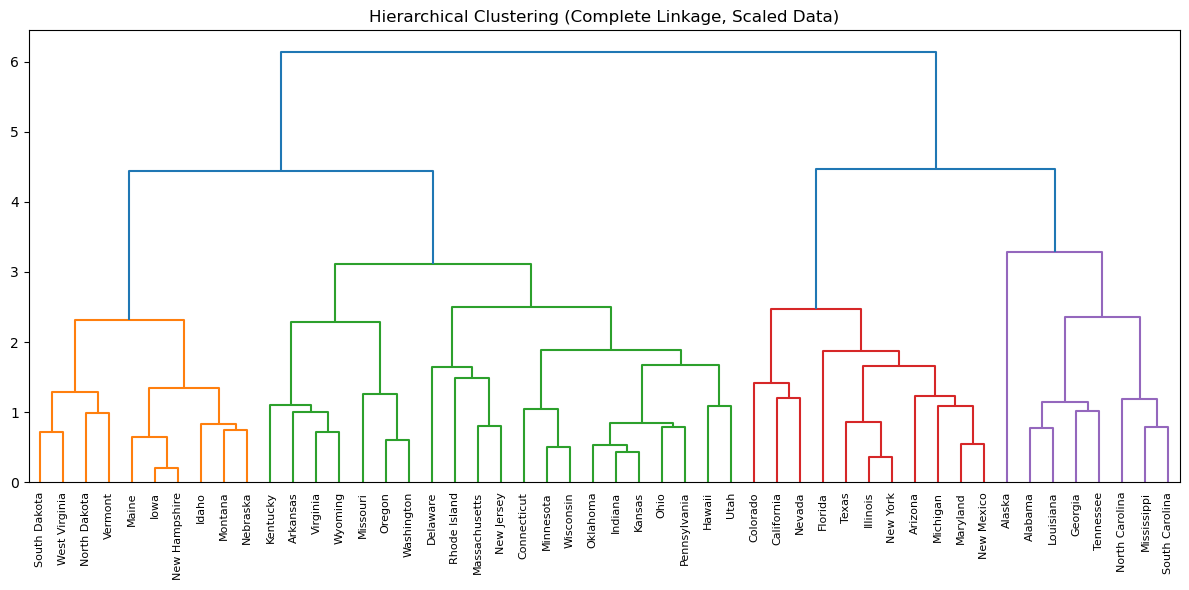


Scaled Cluster 1:
['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

Scaled Cluster 2:
['Arizona', 'California', 'Colorado', 'Florida', 'Illinois', 'Maryland', 'Michigan', 'Nevada', 'New Mexico', 'New York', 'Texas']

Scaled Cluster 3:
['Alabama', 'Alaska', 'Georgia', 'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 'Tennessee']


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.iloc[:, :4])

Z_scaled = linkage(df_scaled, method='complete', metric='euclidean')

plt.figure(figsize=(12,6))
dendrogram(Z_scaled, labels=df.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering (Complete Linkage, Scaled Data)")
plt.tight_layout()
plt.show()

clusters_scaled = fcluster(Z_scaled, 3, criterion='maxclust')

df["Cluster_Scaled"] = clusters_scaled

for cluster in sorted(df["Cluster_Scaled"].unique()):
    print(f"\nScaled Cluster {cluster}:")
    print(df[df["Cluster_Scaled"] == cluster].index.tolist())